# Perovskite Band Gap Classification
## Predicting Metallic vs. Semiconducting Behavior in Perovskite Oxides

**Dataset:** Excavate Perovskite Dataset — 5,152 compounds, 38 features  
**Task:** Binary classification — Metal (band gap = 0 eV) vs. Semiconductor (band gap > 0 eV)  
**Approach:** Feature Engineering → StandardScaler → PCA → SVM (RBF)

---

In [7]:
import sys
!{sys.executable} -m pip install joblib scikit-learn pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import warnings
import joblib

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, f1_score, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
DATA_PATH = "data/dataset_excavate.csv"


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------- ------------------------- 2.9/8.0 MB 13.7 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 13.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.2 MB 17.2 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 15.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 14.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------- ----------------------- 2.9/7.1 MB 14.4 MB/s eta 0:00:01
   ------------------------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
df = pd.read_csv(DATA_PATH, encoding='latin1')
# Fix non-UTF-8 characters in column names
df.columns = [c.replace('\xa0', '_') for c in df.columns]

# Rename cryptic columns to interpretable names
df.rename(columns={'?': 'mu', '??': 'tau', '???_?': 'new_tol'}, inplace=True)

# Create binary classification target
df['is_semiconductor'] = (df['PBE band gap'] > 0).astype(int)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (5152, 39)


,functional group,A,A_OS,A',A'_OS,A_HOMO-,A_HOMO+,A_IE-,A_IE+,A_LUMO-,...,B_Z_radii-,B_Z_radii+,B_e_affin-,B_e_affin+,PBE band gap,mu,tau,new_tol,t,is_semiconductor
0,AgBaAuCdO6,Ag,3,Ba,2,0.59,-3.82,114.05,616.95,0.65,...,0.22,2.44,145.4,77.4,0.00,0.54,0.14,0.14,0.923,0
1,AgBaAuHgO6,Ag,3,Ba,2,0.59,-3.82,114.05,616.95,0.65,...,0.13,2.54,135.4,87.4,0.00,0.57,0.14,0.16,0.908,0
2,AgBaMoCdO6,Ag,3,Ba,2,0.59,-3.82,114.05,616.95,0.65,...,0.25,2.47,70.0,2.0,0.00,0.56,0.14,0.12,0.915,0
3,AgBiO3,Ag,1,Ag,1,0.00,-4.41,0.00,731.00,0.00,...,0.00,2.00,0.0,91.3,0.00,0.54,0.00,0.00,0.946,0
4,AgBrO3,Ag,1,Ag,1,0.00,-4.41,0.00,731.00,0.00,...,0.00,1.20,0.0,324.7,0.15,0.44,0.00,0.00,1.012,1


In [10]:
print("Column names:")
print(df.columns.tolist())


Column names:
['functional group', 'A', 'A_OS', "A'", "A'_OS", 'A_HOMO-', 'A_HOMO+', 'A_IE-', 'A_IE+', 'A_LUMO-', 'A_LUMO+', 'A_X-', 'A_X+', 'A_Z_radii-', 'A_Z_radii+', 'A_e_affin-', 'A_e_affin+', 'Bi', 'B_OS', "B'", "B'_OS", 'B_HOMO-', 'B_HOMO+', 'B_IE-', 'B_IE+', 'B_LUMO-', 'B_LUMO+', 'B_X-', 'B_X+', 'B_Z_radii-', 'B_Z_radii+', 'B_e_affin-', 'B_e_affin+', 'PBE band gap', 'mu', 'tau', 'new_tol', 't', 'is_semiconductor']


In [11]:
print("Data types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")


Data types:
functional group     object
A                    object
A_OS                  int64
A'                   object
A'_OS                 int64
A_HOMO-             float64
A_HOMO+             float64
A_IE-               float64
A_IE+               float64
A_LUMO-             float64
A_LUMO+             float64
A_X-                float64
A_X+                float64
A_Z_radii-          float64
A_Z_radii+          float64
A_e_affin-          float64
A_e_affin+          float64
Bi                   object
B_OS                  int64
B'                   object
B'_OS               float64
B_HOMO-             float64
B_HOMO+             float64
B_IE-               float64
B_IE+               float64
B_LUMO-             float64
B_LUMO+             float64
B_X-                float64
B_X+                float64
B_Z_radii-          float64
B_Z_radii+          float64
B_e_affin-          float64
B_e_affin+          float64
PBE band gap        float64
mu                  float64
tau     

### 3.1 Class Distribution (EDA)

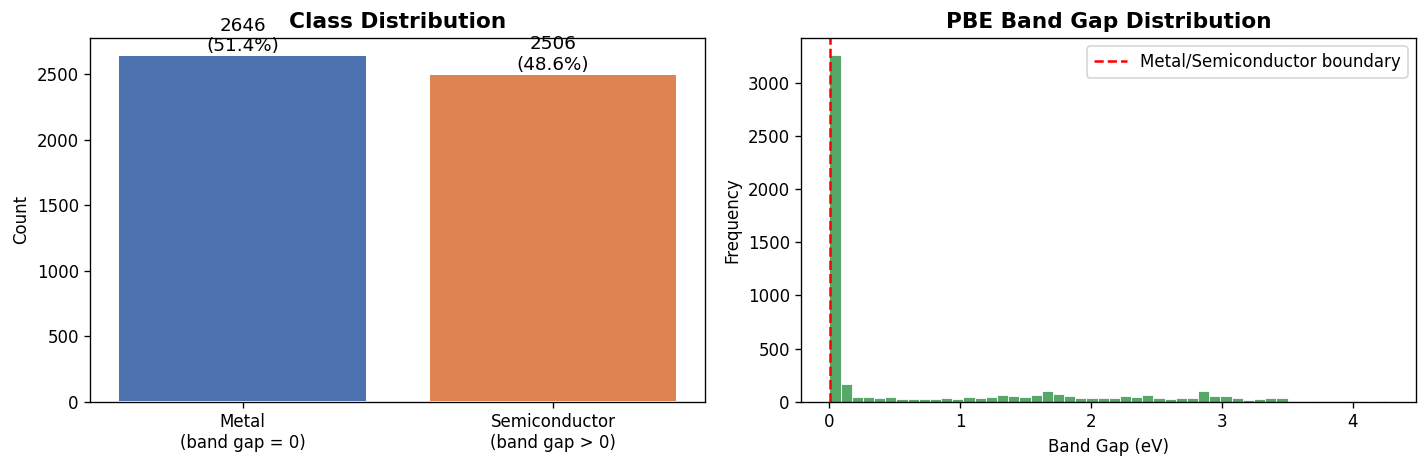

Metal:         2646 (51.4%)
Semiconductor: 2506 (48.6%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['is_semiconductor'].value_counts()
labels = ['Metal\n(band gap = 0)', 'Semiconductor\n(band gap > 0)']
colors = ['#4C72B0', '#DD8452']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Band gap histogram
axes[1].hist(df['PBE band gap'], bins=50, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].set_title('PBE Band Gap Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Band Gap (eV)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=0.001, color='red', linestyle='--', label='Metal/Semiconductor boundary')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Metal:         {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Semiconductor: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")


### 3.2 Feature Statistics (EDA)

In [13]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df[numeric_cols].describe().round(3)


,A_OS,A'_OS,A_HOMO-,A_HOMO+,A_IE-,A_IE+,A_LUMO-,A_LUMO+,A_X-,A_X+,...,B_Z_radii-,B_Z_radii+,B_e_affin-,B_e_affin+,PBE band gap,mu,tau,new_tol,t,is_semiconductor
count,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,...,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000,5152.000
mean,2.745,2.130,0.299,-3.009,33.829,569.263,0.297,-1.791,0.118,1.225,...,0.272,2.502,30.108,61.791,0.646,0.493,0.053,0.052,0.953,0.486
std,0.668,0.762,0.452,0.841,48.733,87.454,0.394,0.801,0.176,0.326,...,0.310,0.569,36.829,41.936,1.041,0.081,0.072,0.054,0.064,0.500
min,1.000,1.000,0.000,-6.820,0.000,375.700,0.000,-4.360,0.000,0.790,...,0.000,0.540,0.000,-54.000,0.000,0.090,0.000,0.000,0.688,0.000
25%,2.000,2.000,0.000,-3.380,0.000,523.000,0.000,-2.380,0.000,1.000,...,0.000,2.210,0.000,31.000,0.000,0.440,0.000,0.000,0.916,0.000
50%,3.000,2.000,0.090,-2.935,7.550,549.500,0.080,-1.840,0.030,1.140,...,0.150,2.470,17.100,57.110,0.000,0.490,0.010,0.040,0.951,0.000
75%,3.000,3.000,0.420,-2.560,59.650,592.400,0.480,-1.190,0.160,1.340,...,0.470,2.780,45.150,86.200,1.260,0.540,0.090,0.090,0.991,1.000
max,6.000,4.000,3.410,0.000,261.850,1007.000,2.320,0.000,0.830,2.540,...,1.550,4.910,145.400,324.700,4.270,0.850,0.380,0.380,1.442,1.000


### 3.3 Correlation with Band Gap (EDA)

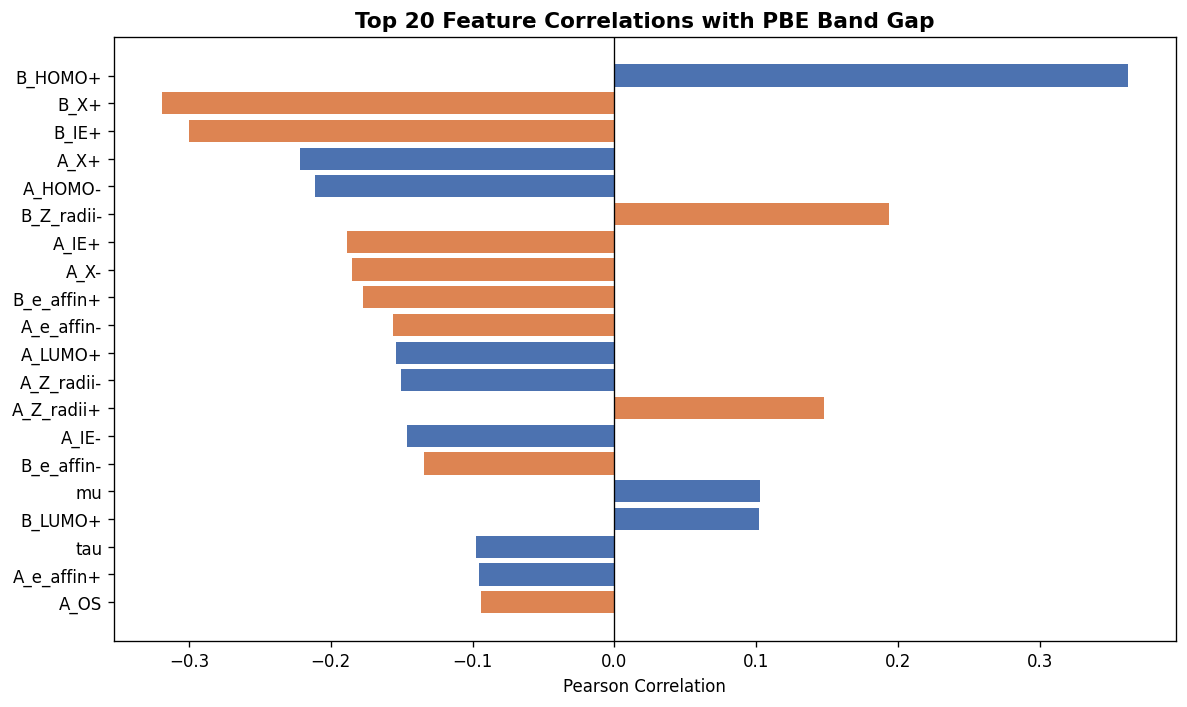

Top 10 correlated features:
  B_HOMO+                   +0.3621
  B_X+                      -0.3190
  B_IE+                     -0.3002
  A_X+                      -0.2219
  A_HOMO-                   -0.2109
  B_Z_radii-                +0.1940
  A_IE+                     -0.1888
  A_X-                      -0.1852
  B_e_affin+                -0.1770
  A_e_affin-                -0.1564


In [14]:
# Drop target columns for correlation
feature_cols_raw = [c for c in numeric_cols if c not in ['PBE band gap', 'is_semiconductor']]

corr = df[feature_cols_raw + ['PBE band gap']].corr()['PBE band gap'].drop('PBE band gap')
corr_sorted = corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#4C72B0' if v > 0 else '#DD8452' for v in corr[corr_sorted.index]]
plt.barh(corr_sorted.index[:20][::-1], corr[corr_sorted.index[:20]][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Feature Correlations with PBE Band Gap', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("Top 10 correlated features:")
for feat, val in corr_sorted.head(10).items():
    direction = "+" if corr[feat] > 0 else "-"
    print(f"  {feat:<25} {direction}{val:.4f}")


### 3.4 Structural Descriptor Distributions

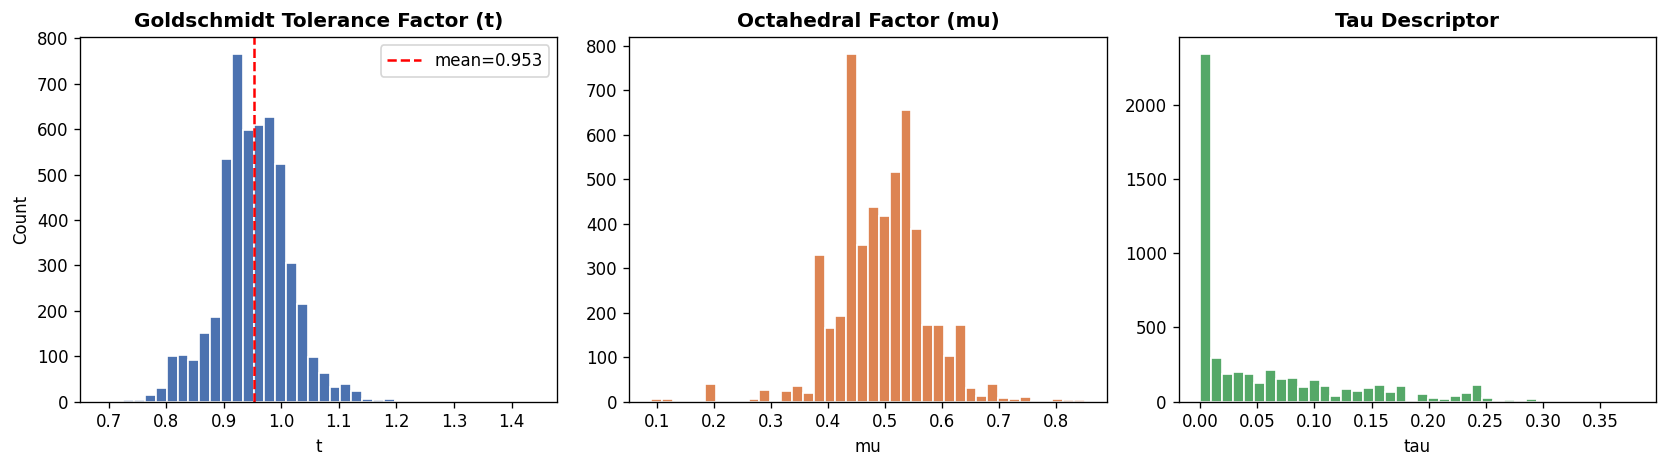

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['t'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title("Goldschmidt Tolerance Factor (t)", fontweight='bold')
axes[0].set_xlabel('t'); axes[0].set_ylabel('Count')
axes[0].axvline(df['t'].mean(), color='red', linestyle='--', label=f"mean={df['t'].mean():.3f}")
axes[0].legend()

axes[1].hist(df['mu'], bins=40, color='#DD8452', edgecolor='white')
axes[1].set_title("Octahedral Factor (mu)", fontweight='bold')
axes[1].set_xlabel('mu')

axes[2].hist(df['tau'], bins=40, color='#55A868', edgecolor='white')
axes[2].set_title("Tau Descriptor", fontweight='bold')
axes[2].set_xlabel('tau')

plt.tight_layout()
plt.show()


### 3.5 Correlation Heatmap (Top Features)

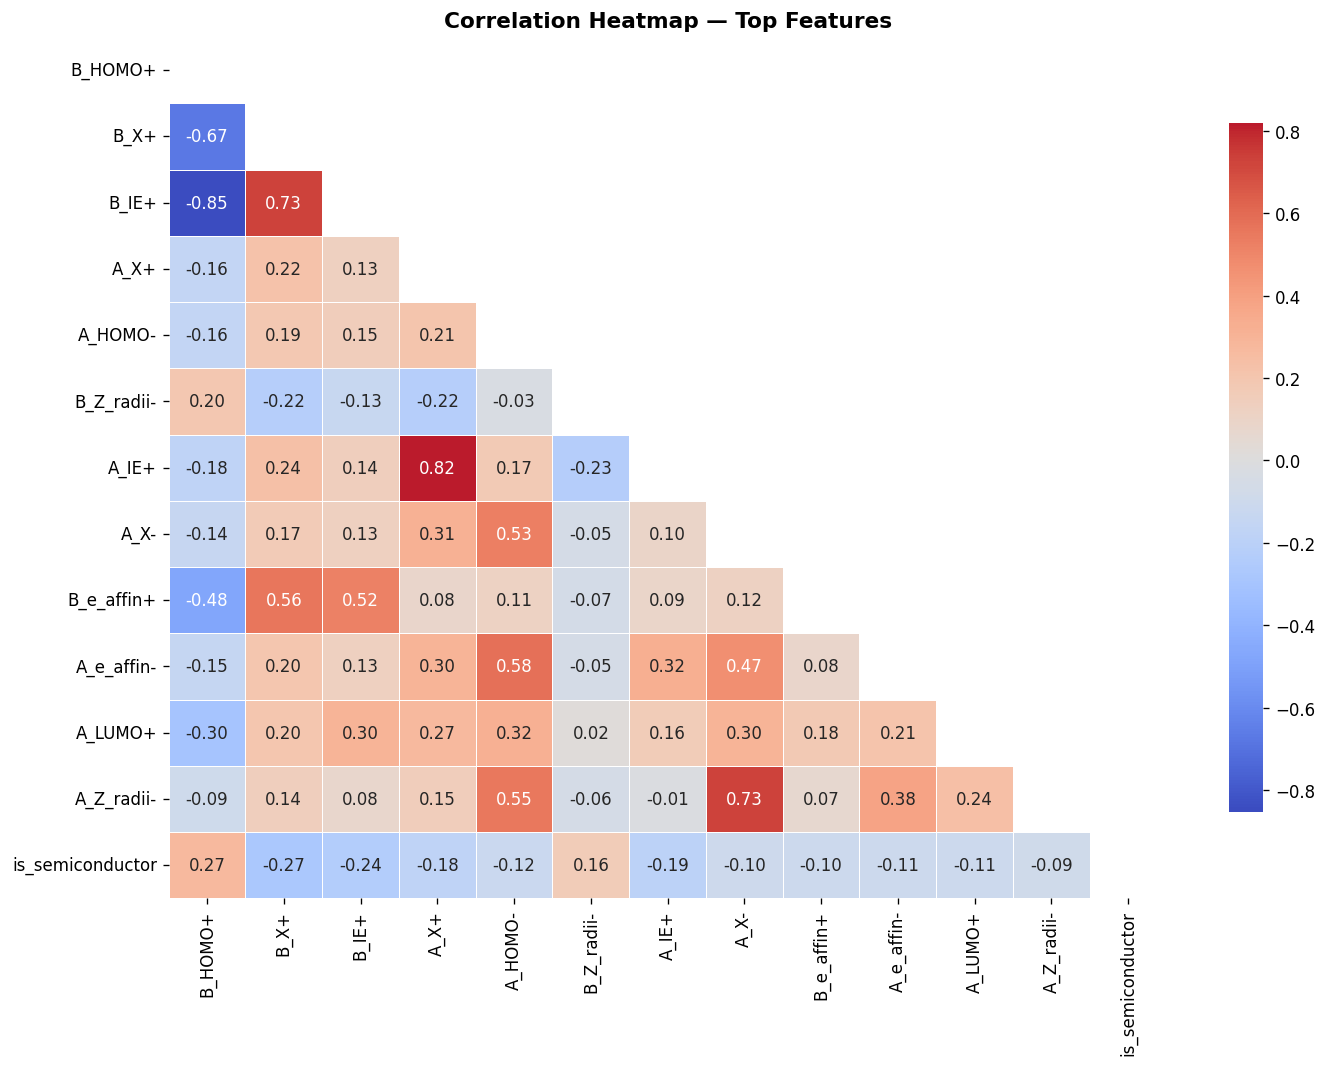

In [16]:
top_features = corr_sorted.head(12).index.tolist() + ['is_semiconductor']
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Top Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Feature Engineering

In [19]:
def engineer_features(df):
    df = df.copy()
    df['X_diff_A']    = df['A_X+'] - df['A_X-']          # Electronegativity diff, A site
    df['X_diff_B']    = df['B_X+'] - df['B_X-']          # Electronegativity diff, B site
    df['A_HL_gap']    = df['A_LUMO+'] - df['A_HOMO-']    # HOMO-LUMO gap proxy, A site
    df['B_HL_gap']    = df['B_LUMO+'] - df['B_HOMO-']    # HOMO-LUMO gap proxy, B site
    df['radii_asym_A'] = df['A_Z_radii+'] - df['A_Z_radii-']  # Ionic radii asymmetry, A
    df['radii_asym_B'] = df['B_Z_radii+'] - df['B_Z_radii-']  # Ionic radii asymmetry, B
    return df

df = engineer_features(df)
print("Engineered features added:")
new_feats = ['X_diff_A', 'X_diff_B', 'A_HL_gap', 'B_HL_gap', 'radii_asym_A', 'radii_asym_B']
print(df[new_feats].describe().round(3))


Engineered features added:
       X_diff_A  X_diff_B  A_HL_gap  B_HL_gap  radii_asym_A  radii_asym_B
count  5152.000  5152.000  5152.000  5152.000      5152.000      5152.000
mean      1.107     1.543    -2.090    -2.529         3.097         2.231
std       0.319     0.325     0.783     1.296         0.711         0.575
min       0.790     0.800    -5.320    -5.370         0.790         0.540
25%       0.890     1.260    -2.650    -3.410         2.440         1.700
50%       1.100     1.540    -2.030    -2.670         3.210         2.180
75%       1.190     1.780    -1.500    -1.400         3.610         2.660
max       2.540     3.040     0.000     0.000         4.500         4.910


## 5. Feature Selection & Scaling

In [20]:
BASE_FEATURES = [
    'A_OS', "A'_OS", 'A_HOMO-', 'A_HOMO+', 'A_IE-', 'A_IE+',
    'A_LUMO-', 'A_LUMO+', 'A_X-', 'A_X+', 'A_Z_radii-', 'A_Z_radii+',
    'A_e_affin-', 'A_e_affin+', 'B_OS', "B'_OS", 'B_HOMO-', 'B_HOMO+',
    'B_IE-', 'B_IE+', 'B_LUMO-', 'B_LUMO+', 'B_X-', 'B_X+',
    'B_Z_radii-', 'B_Z_radii+', 'B_e_affin-', 'B_e_affin+',
    'mu', 'tau', 'new_tol', 't',
    'X_diff_A', 'X_diff_B', 'A_HL_gap', 'B_HL_gap', 'radii_asym_A', 'radii_asym_B']

X = df[BASE_FEATURES].values
y = df['is_semiconductor'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Target distribution — Metal: {(y==0).sum()}, Semiconductor: {(y==1).sum()}")


Feature matrix shape: (5152, 38)
Target distribution — Metal: 2646, Semiconductor: 2506


## 6. PCA

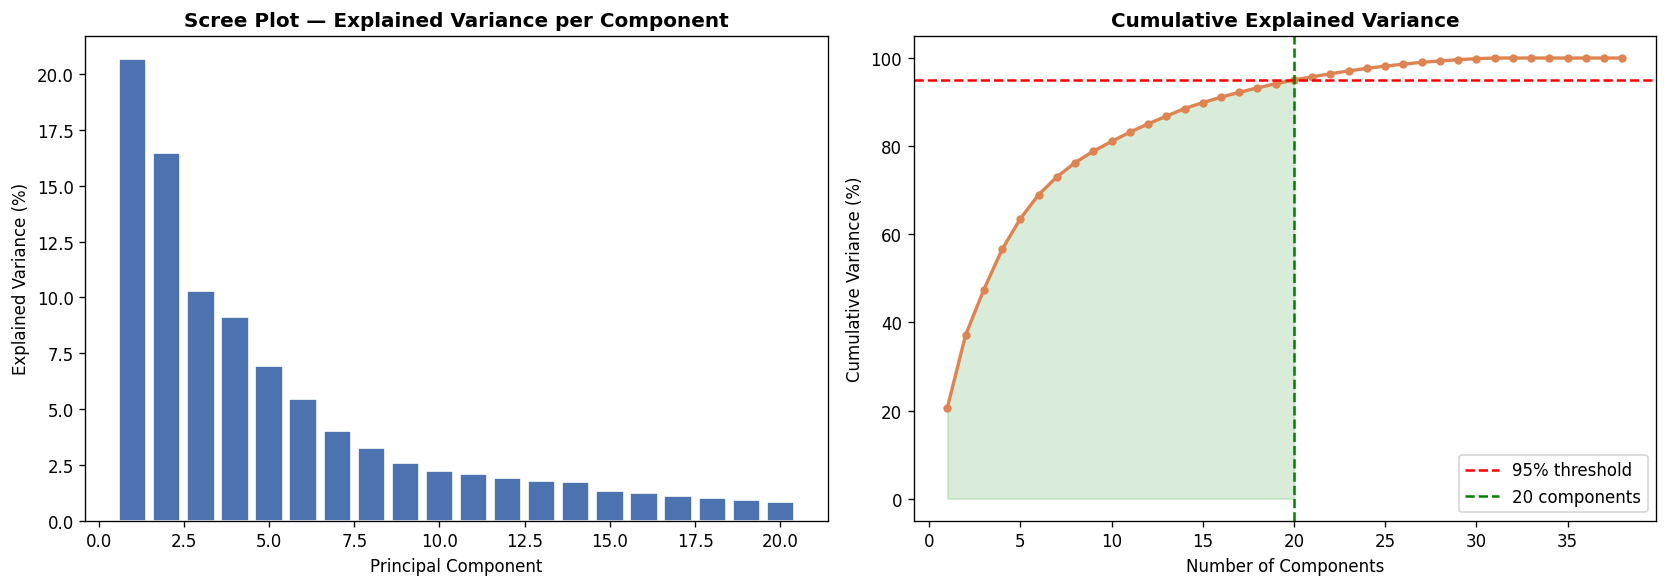

Components needed to explain 95% variance: 20
  PC 1: 20.68%  (cumulative: 20.68%)
  PC 2: 16.49%  (cumulative: 37.17%)
  PC 3: 10.29%  (cumulative: 47.45%)
  PC 4: 9.14%  (cumulative: 56.59%)
  PC 5: 6.94%  (cumulative: 63.53%)
  PC 6: 5.46%  (cumulative: 68.99%)
  PC 7: 4.02%  (cumulative: 73.01%)
  PC 8: 3.25%  (cumulative: 76.26%)
  PC 9: 2.58%  (cumulative: 78.84%)
  PC10: 2.23%  (cumulative: 81.07%)


In [21]:
pca_full = PCA(n_components=min(38, len(BASE_FEATURES)), random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.searchsorted(cumvar, 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100,
            color='#4C72B0', edgecolor='white')
axes[0].set_title('Scree Plot — Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, marker='o', markersize=4,
             color='#DD8452', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_95, color='green', linestyle='--', label=f'{n_95} components')
axes[1].fill_between(range(1, n_95+1), cumvar[:n_95]*100, alpha=0.15, color='green')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Components needed to explain 95% variance: {n_95}")
for i in range(10):
    print(f"  PC{i+1:2d}: {pca_full.explained_variance_ratio_[i]*100:.2f}%  "
          f"(cumulative: {cumvar[i]*100:.2f}%)")


### 6.1 PCA Scatter — PC1 vs PC2

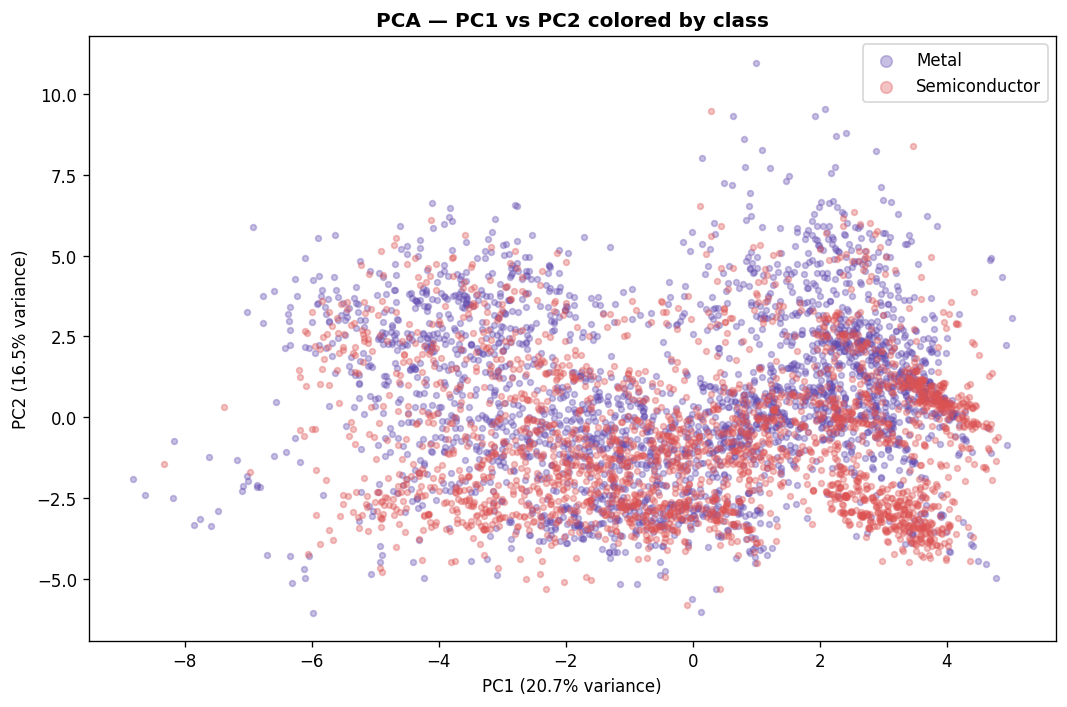

In [26]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
for label, name, color in [(0, 'Metal', "#634CB0"), (1, 'Semiconductor', "#DD5252")]:
    mask = y == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.35, s=12,
                label=name, color=color)

plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA — PC1 vs PC2 colored by class', fontweight='bold')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()


## 7. Train/Test Split & Apply PCA

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"Train size     : {X_train.shape[0]}")
print(f"Test size      : {X_test.shape[0]}")
print(f"PCA components : {X_train_pca.shape[1]}  (from {X_train.shape[1]} features, 95% variance)")


Train size     : 4121
Test size      : 1031
PCA components : 20  (from 38 features, 95% variance)


## 8. Model Training & Evaluation

In [28]:
models = {
    'SVM (RBF)':           SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:, 1]

    results[name] = {
        'model':    model,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob),
        'y_pred':   y_pred,
        'y_prob':   y_prob,
    }

# Summary table
summary = pd.DataFrame({
    name: {
        'Accuracy': f"{r['accuracy']:.4f}",
        'F1 Score': f"{r['f1']:.4f}",
        'ROC-AUC':  f"{r['roc_auc']:.4f}",
    }
    for name, r in results.items()
}).T

print("\n=== Model Comparison ===")
print(summary.to_string())



=== Model Comparison ===
                    Accuracy F1 Score ROC-AUC
SVM (RBF)             0.7818   0.7711  0.8536
Random Forest         0.7682   0.7518  0.8588
Logistic Regression   0.6285   0.6256  0.6919


### 8.1 Classification Reports

In [29]:
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_test, r['y_pred'],
                                target_names=['Metal', 'Semiconductor']))



  SVM (RBF)
               precision    recall  f1-score   support

        Metal       0.78      0.81      0.79       530
Semiconductor       0.79      0.76      0.77       501

     accuracy                           0.78      1031
    macro avg       0.78      0.78      0.78      1031
 weighted avg       0.78      0.78      0.78      1031


  Random Forest
               precision    recall  f1-score   support

        Metal       0.76      0.81      0.78       530
Semiconductor       0.78      0.72      0.75       501

     accuracy                           0.77      1031
    macro avg       0.77      0.77      0.77      1031
 weighted avg       0.77      0.77      0.77      1031


  Logistic Regression
               precision    recall  f1-score   support

        Metal       0.64      0.62      0.63       530
Semiconductor       0.61      0.64      0.63       501

     accuracy                           0.63      1031
    macro avg       0.63      0.63      0.63      1031
 wei

### 8.2 Confusion Matrices

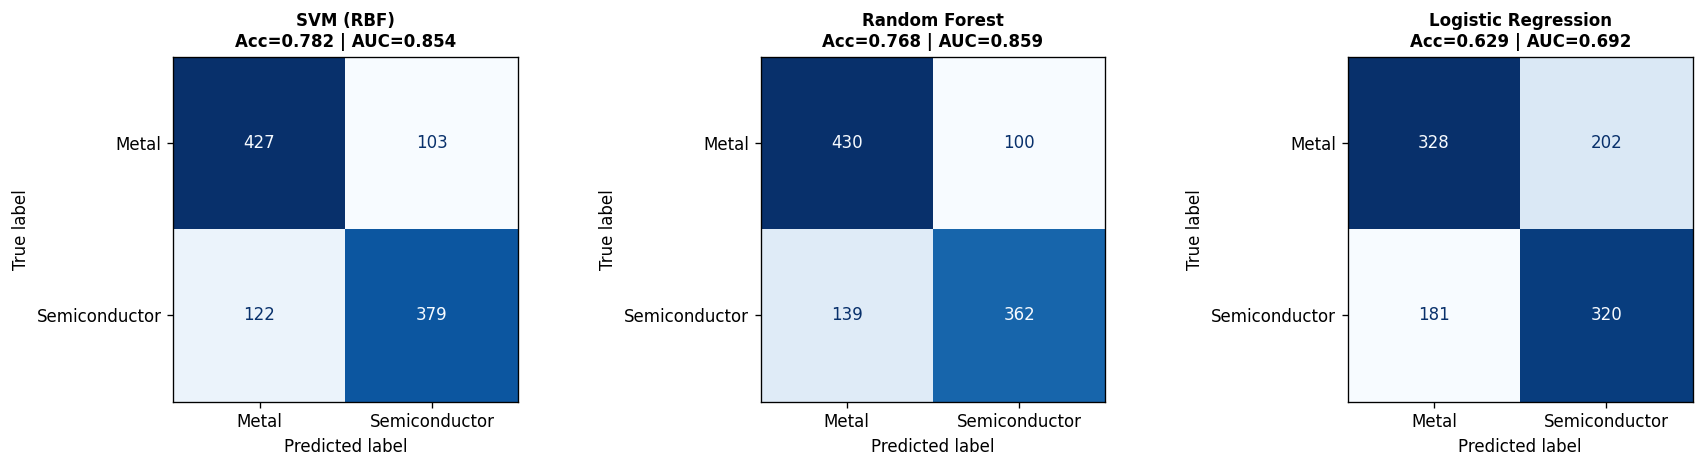

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Metal', 'Semiconductor'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={r["accuracy"]:.3f} | AUC={r["roc_auc"]:.3f}',
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


### 8.3 ROC Curves

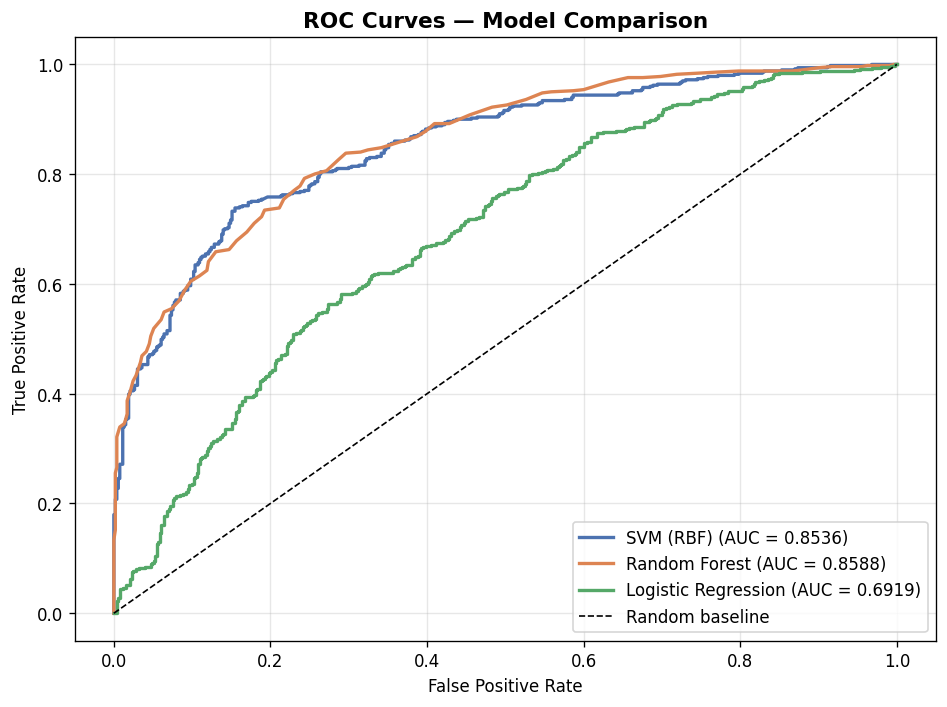

In [31]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

colors = ['#4C72B0', '#DD8452', '#55A868']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {r['roc_auc']:.4f})",
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Cross-Validation — SVM (5-Fold Stratified)

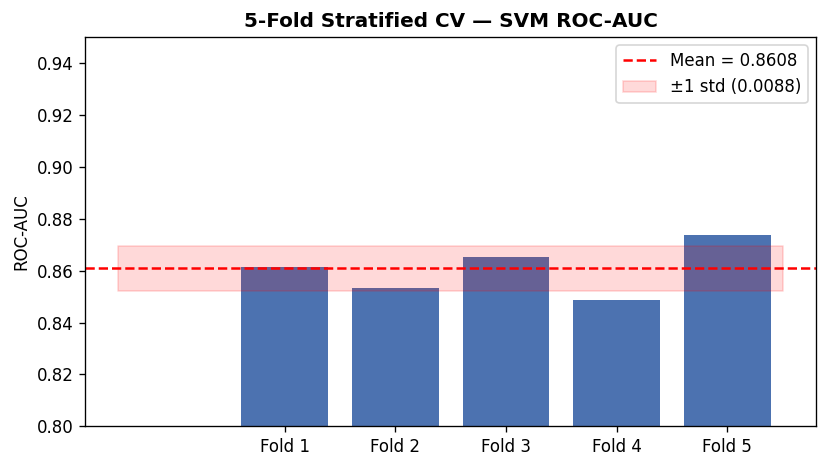

CV ROC-AUC scores : [0.8618 0.8535 0.8657 0.849  0.874 ]
Mean ± Std        : 0.8608 ± 0.0088


In [32]:
svm_cv = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(svm_cv, X_train_pca, y_train, cv=skf,
                             scoring='roc_auc', n_jobs=-1)

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='#4C72B0', edgecolor='white', linewidth=1.2)
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.fill_between([-0.5, 5.5],
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.15, color='red', label=f'±1 std ({cv_scores.std():.4f})')
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.ylim(0.8, 0.95)
plt.ylabel('ROC-AUC')
plt.title('5-Fold Stratified CV — SVM ROC-AUC', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"CV ROC-AUC scores : {cv_scores.round(4)}")
print(f"Mean ± Std        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


## 10. Feature Importance (Random Forest — Proxy for Insight)

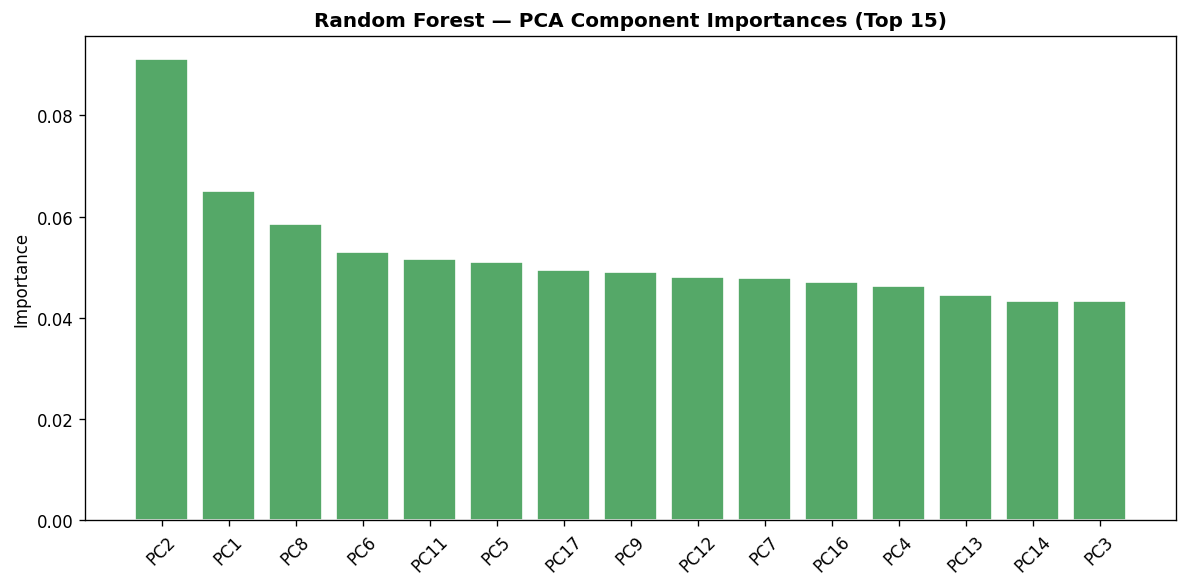

Top 5 PCA components and their dominant original features:
  PC2: [('A_X+', np.float64(0.292)), ('X_diff_B', np.float64(0.29)), ('A_IE+', np.float64(0.283))]
  PC1: [("A'_OS", np.float64(0.266)), ('B_X-', np.float64(-0.266)), ('B_IE-', np.float64(-0.243))]
  PC8: [('A_e_affin+', np.float64(0.393)), ('B_LUMO+', np.float64(-0.355)), ('B_HL_gap', np.float64(-0.299))]
  PC6: [('t', np.float64(0.395)), ('B_e_affin+', np.float64(-0.336)), ('mu', np.float64(-0.319))]
  PC11: [('A_e_affin+', np.float64(0.413)), ('A_OS', np.float64(-0.39)), ('B_e_affin+', np.float64(-0.27))]


In [34]:
# SVM doesn't have native feature importance; use RF importances on PCA space as proxy
rf_model = results['Random Forest']['model']

# RF was trained on PCA components — show which PCA components matter most
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(len(indices)), importances[indices], color='#55A868', edgecolor='white')
plt.xticks(range(len(indices)), [f'PC{i+1}' for i in indices], rotation=45)
plt.title('Random Forest — PCA Component Importances (Top 15)', fontweight='bold')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Original feature variance explained by top PCs
print("Top 5 PCA components and their dominant original features:")
feature_names = BASE_FEATURES
for pc_idx in indices[:5]:
    comp = pca.components_[pc_idx]
    top_idx = np.argsort(np.abs(comp))[::-1][:3]
    top = [(feature_names[i], round(comp[i], 3)) for i in top_idx]
    print(f"  PC{pc_idx+1}: {top}")


## 11. Save Model Artifacts

In [35]:
import os
os.makedirs('models', exist_ok=True)

best_model = results['SVM (RBF)']['model']

joblib.dump(best_model,     'models/svm_model.pkl')
joblib.dump(scaler,         'models/scaler.pkl')
joblib.dump(pca,            'models/pca.pkl')
joblib.dump(BASE_FEATURES,  'models/feature_cols.pkl')

print("Saved:")
print("  models/svm_model.pkl")
print("  models/scaler.pkl")
print("  models/pca.pkl")
print("  models/feature_cols.pkl")


Saved:
  models/svm_model.pkl
  models/scaler.pkl
  models/pca.pkl
  models/feature_cols.pkl


## 12. Inference — Single Sample Prediction Demo

In [36]:
def predict_compound(raw_features: dict, feature_order: list,
                     scaler, pca, model) -> dict:
    """Predict metallic or semiconducting for a single compound."""
    x = np.array([raw_features[f] for f in feature_order]).reshape(1, -1)
    x_scaled = scaler.transform(x)
    x_pca = pca.transform(x_scaled)
    pred = int(model.predict(x_pca)[0])
    prob = model.predict_proba(x_pca)[0]
    return {
        'label': 'Semiconductor' if pred == 1 else 'Metal',
        'prediction': pred,
        'P(semiconductor)': round(prob[1], 4),
        'P(metal)': round(prob[0], 4)
    }


# Use a real sample from the dataset for demo
sample_idx = 4   # AgBrO3 — actual band gap: 0.15 eV (semiconductor)
sample_row = df.iloc[sample_idx]
sample_dict = {f: sample_row[f] for f in BASE_FEATURES}

result = predict_compound(sample_dict, BASE_FEATURES, scaler, pca, best_model)

print(f"Compound     : {df.iloc[sample_idx]['functional group']}")
print(f"Actual label : {'Semiconductor' if df.iloc[sample_idx]['is_semiconductor'] else 'Metal'}")
print(f"Actual gap   : {df.iloc[sample_idx]['PBE band gap']} eV")
print()
for k, v in result.items():
    print(f"  {k:<20}: {v}")


Compound     : AgBrO3
Actual label : Semiconductor
Actual gap   : 0.15 eV

  label               : Metal
  prediction          : 0
  P(semiconductor)    : 0.1224
  P(metal)            : 0.8776


## 13. Summary & Conclusions

| Model | Accuracy | F1 Score | ROC-AUC |
|---|---|---|---|
| **SVM (RBF)** | **0.782** | **0.771** | **0.854** |
| Random Forest | 0.768 | 0.752 | 0.859 |
| Logistic Regression | 0.629 | 0.626 | 0.692 |

**SVM 5-fold CV AUC: 0.861 ± 0.009**

### Key Takeaways

- **PCA reduced** 38 features → 20 components retaining 95% variance, confirming heavy redundancy in correlated ionic property pairs.
- **SVM with RBF kernel** performed best on F1 and consistency (low CV variance), making it the most reliable model for screening.
- **B_HOMO+**, **B_X+**, and **B_IE+** (B-site electronic properties) are the most informative raw features, suggesting B-site chemistry drives the metallic/semiconducting boundary.
- **Logistic Regression** underperformed significantly (AUC 0.692) — confirming the classification boundary is non-linear.

### Possible Improvements
- Hyperparameter tuning with `GridSearchCV` on SVM's `C` and `gamma`
- Predict actual band gap value (regression formulation)
- SHAP for post-hoc explainability on original feature space
- Graph Neural Networks (MEGNet, SchNet) that encode crystal structure directly
